Загрузка Elliptic (Bitcoin)...
  Узлов: 46564, рёбер: 36624
Загрузка Amazon Reviews...
  Узлов: 11944, рёбер: 1036737
Загрузка Yelp Reviews...
  Узлов: 45954, рёбер: 49315
Загрузка MGTAB...
  Узлов: 10199, рёбер: 908460


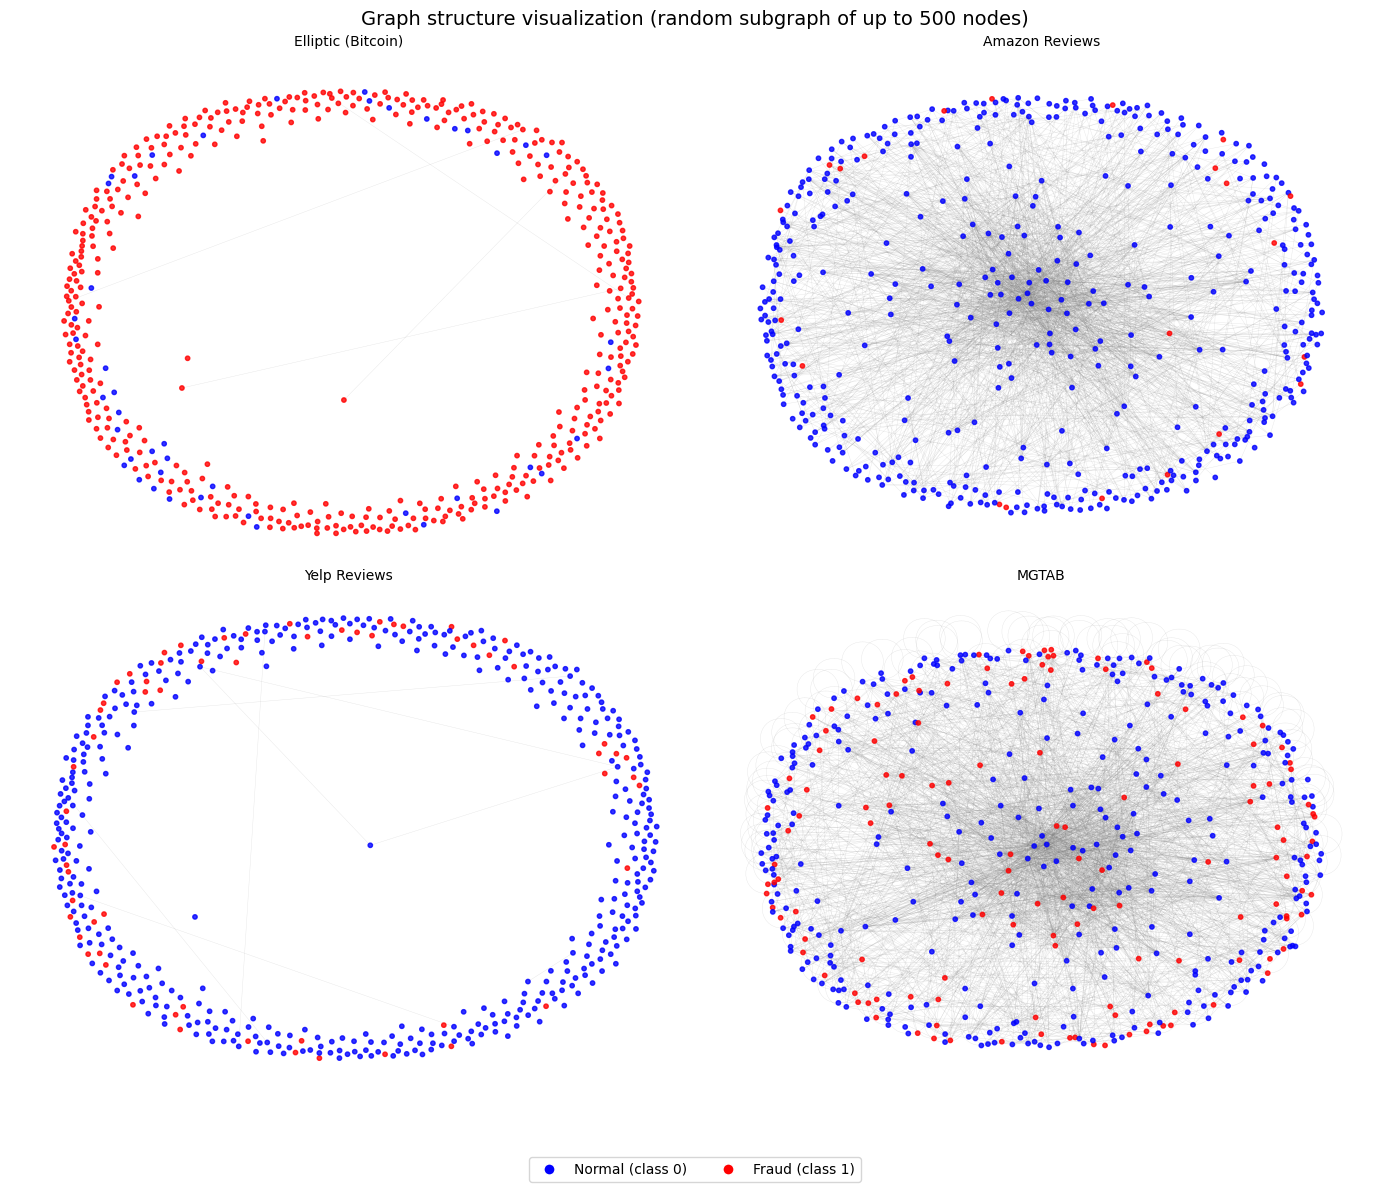

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

DATA_ROOT = "final_data"

def load_elliptic():
    feat_path = os.path.join(DATA_ROOT, "Elliptic", "elliptic_txs_features.csv")
    edge_path = os.path.join(DATA_ROOT, "Elliptic", "elliptic_txs_edgelist.csv")
    class_path = os.path.join(DATA_ROOT, "Elliptic", "elliptic_txs_classes.csv")

    df_feat = pd.read_csv(feat_path, header=None, low_memory=False)
    df_feat.columns = ['txId', 'time_step'] + [f'f{i}' for i in range(df_feat.shape[1]-2)]
    df_class = pd.read_csv(class_path)
    df_class = df_class[df_class['class'].isin(['1','2'])].copy()
    df_class['label'] = df_class['class'].map({'1':0, '2':1})
    df = df_feat.merge(df_class[['txId', 'label']], on='txId', how='inner')
    tx_ids = df['txId'].astype(str).values
    y = df['label'].values

    edges_df = pd.read_csv(edge_path, header=None)
    id_to_idx = {tid: i for i, tid in enumerate(tx_ids)}
    G = nx.Graph()
    for i, label in enumerate(y):
        G.add_node(i, label=label)
    for _, row in edges_df.iterrows():
        src = str(row[0]); dst = str(row[1])
        if src in id_to_idx and dst in id_to_idx:
            G.add_edge(id_to_idx[src], id_to_idx[dst])
    return G, list(y)

def load_amazon():
    edge_path = os.path.join(DATA_ROOT, "Amazon", "Amazon_net_uvu_edges.csv")
    label_path = os.path.join(DATA_ROOT, "Amazon", "Amazon_full.csv")
    df_labels = pd.read_csv(label_path, header=None, skiprows=1, low_memory=False)
    y = df_labels.iloc[:, -1].values.astype(np.int64)
    edges = pd.read_csv(edge_path)[['row', 'col']].values
    N = len(y)
    G = nx.Graph()
    for i in range(N):
        G.add_node(i, label=y[i])
    for src, dst in edges:
        if src < N and dst < N:
            G.add_edge(src, dst)
    return G, list(y)

def load_yelp():
    edge_path = os.path.join(DATA_ROOT, "YelpChi", "YelpChi_net_rur_edges.csv")
    label_path = os.path.join(DATA_ROOT, "YelpChi", "YelpChi_full.csv")
    df_labels = pd.read_csv(label_path)
    y = df_labels.iloc[:, -1].values.astype(np.int64)
    edges = pd.read_csv(edge_path)[['row', 'col']].values
    N = len(y)
    G = nx.Graph()
    for i in range(N):
        G.add_node(i, label=y[i])
    for src, dst in edges:
        if src < N and dst < N:
            G.add_edge(src, dst)
    return G, list(y)

def load_mgtab():
    edge_path = os.path.join(DATA_ROOT, "MGTAB", "edge_index.csv")
    label_path = os.path.join(DATA_ROOT, "MGTAB", "labels_bot.csv")
    df_edges = pd.read_csv(edge_path, header=None, low_memory=False)
    sources = df_edges.iloc[1].values.astype(np.int64)
    targets = df_edges.iloc[2].values.astype(np.int64)
    df_labels = pd.read_csv(label_path, header=None)
    y = df_labels[0].values.astype(np.int64)
    max_node = max(sources.max(), targets.max())
    N = max_node + 1
    G = nx.Graph()
    for i in range(N):
        G.add_node(i, label=-1)
    for i, label in enumerate(y):
        if i < N:
            G.nodes[i]['label'] = label
    for src, dst in zip(sources, targets):
        G.add_edge(src, dst)
    return G, [G.nodes[i]['label'] for i in range(N)]

# ---------- функция для одного подграфика ----------
def draw_subgraph(ax, G, y, title, max_nodes=500, sample_seed=42):
    np.random.seed(sample_seed)
    all_nodes = list(G.nodes())
    if len(all_nodes) == 0:
        ax.text(0.5, 0.5, "Empty graph", transform=ax.transAxes, ha='center')
        ax.set_title(title)
        return
    if len(all_nodes) > max_nodes:
        sampled_nodes = np.random.choice(all_nodes, max_nodes, replace=False)
        subgraph = G.subgraph(sampled_nodes)
    else:
        subgraph = G
    labels = [subgraph.nodes[n].get('label', -1) for n in subgraph.nodes()]
    node_colors = []
    for lbl in labels:
        if lbl == 0:
            node_colors.append('blue')
        elif lbl == 1:
            node_colors.append('red')
        else:
            node_colors.append('gray')
    pos = nx.spring_layout(subgraph, seed=sample_seed, k=1, iterations=50)
    nx.draw_networkx_edges(subgraph, pos, ax=ax, alpha=0.2, edge_color='gray', width=0.3)
    nx.draw_networkx_nodes(subgraph, pos, ax=ax, node_color=node_colors, node_size=10, alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

if __name__ == "__main__":
    datasets = {
        "Elliptic (Bitcoin)": load_elliptic,
        "Amazon Reviews": load_amazon,
        "Yelp Reviews": load_yelp,
        "MGTAB": load_mgtab
    }
    graphs = {}
    for name, loader in datasets.items():
        print(f"Загрузка {name}...")
        G, y = loader()
        graphs[name] = (G, y)
        print(f"  Узлов: {G.number_of_nodes()}, рёбер: {G.number_of_edges()}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    for ax, (name, (G, y)) in zip(axes, graphs.items()):
        draw_subgraph(ax, G, y, name, max_nodes=500, sample_seed=42)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Normal (class 0)', markerfacecolor='blue', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='Fraud (class 1)', markerfacecolor='red', markersize=8),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, frameon=True, fontsize=10)
    plt.suptitle("Graph structure visualization (random subgraph of up to 500 nodes)", fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.savefig("graphs_comparison.png", dpi=150)
    plt.show()

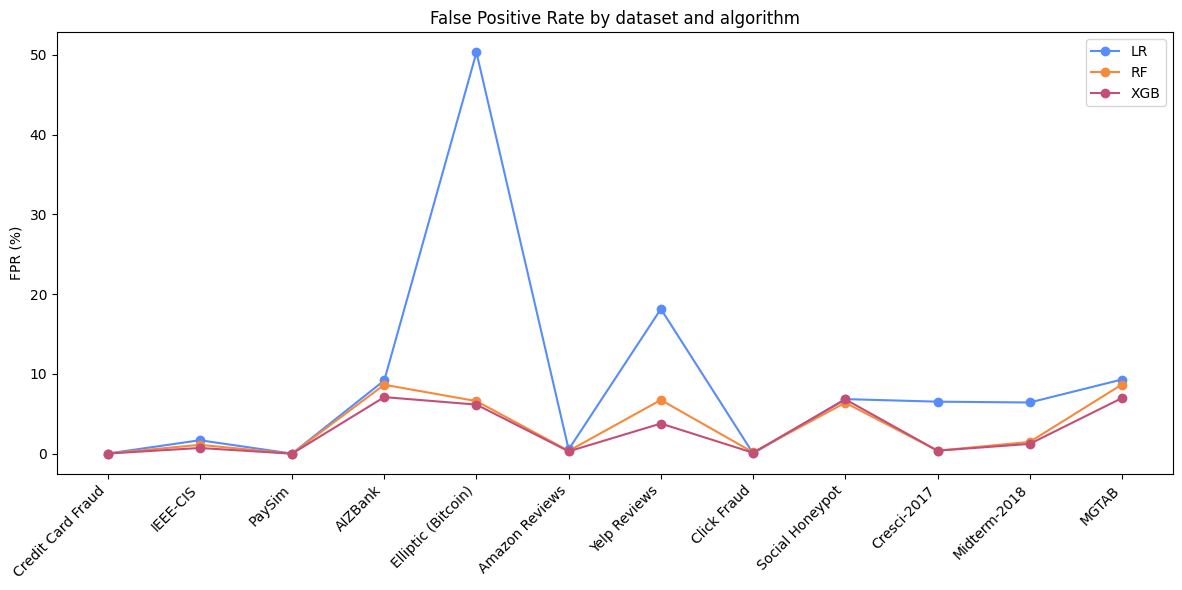

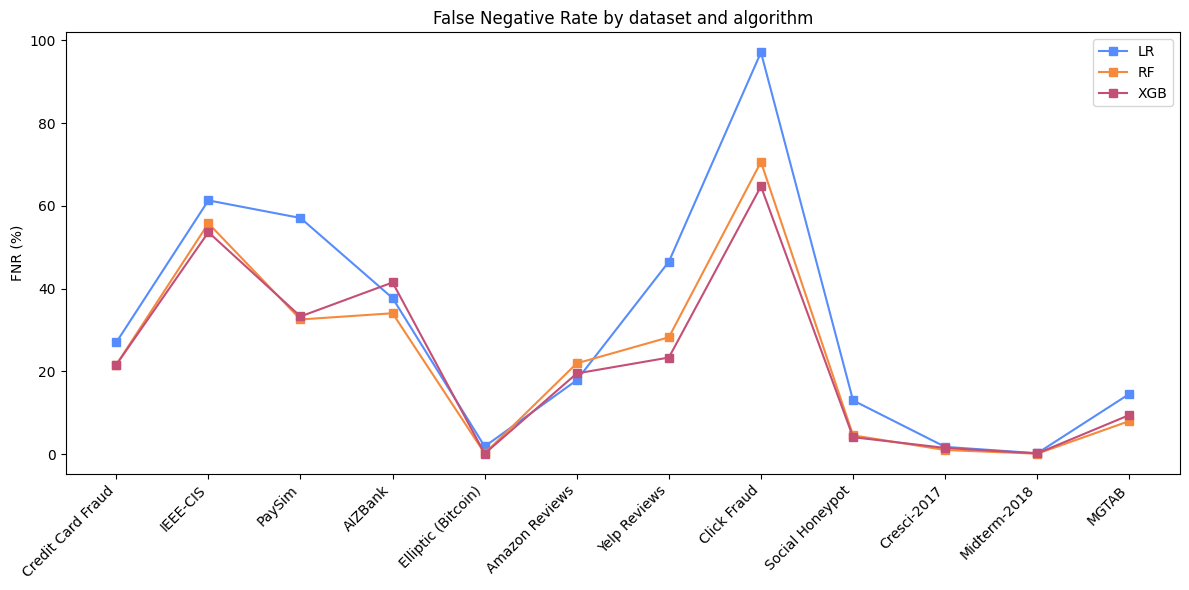

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from io import StringIO
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('confusion_matrices_fast.csv')

def normalize(row):
    pos_total = row['TP'] + row['FN']
    neg_total = row['TN'] + row['FP']
    row['TP_pct'] = row['TP'] / pos_total * 100 if pos_total > 0 else 0
    row['FN_pct'] = row['FN'] / pos_total * 100 if pos_total > 0 else 0
    row['TN_pct'] = row['TN'] / neg_total * 100 if neg_total > 0 else 0
    row['FP_pct'] = row['FP'] / neg_total * 100 if neg_total > 0 else 0
    return row

df_norm = df.apply(normalize, axis=1)

datasets = df['Dataset'].unique()
algorithms = ['LR', 'RF', 'XGB']


fig, ax = plt.subplots(figsize=(12, 6))
for algo in algorithms:
    sub = df_norm[df_norm['Algorithm'] == algo]
    fpr_vals = []
    for ds in datasets:
        val = sub[sub['Dataset'] == ds]['FP_pct'].values
        fpr_vals.append(val[0] if len(val) > 0 else 0)
    ax.plot(datasets, fpr_vals, marker='o', label=algo)
ax.set_xticklabels(datasets, rotation=45, ha='right')
ax.set_ylabel('FPR (%)')
ax.set_title('False Positive Rate by dataset and algorithm')
ax.legend()
plt.tight_layout()
plt.savefig("fpr_comparison.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
for algo in algorithms:
    sub = df_norm[df_norm['Algorithm'] == algo]
    fnr_vals = []
    for ds in datasets:
        val = sub[sub['Dataset'] == ds]['FN_pct'].values
        fnr_vals.append(val[0] if len(val) > 0 else 0)
    ax.plot(datasets, fnr_vals, marker='s', label=algo)
ax.set_xticklabels(datasets, rotation=45, ha='right')
ax.set_ylabel('FNR (%)')
ax.set_title('False Negative Rate by dataset and algorithm')
ax.legend()
plt.tight_layout()
plt.savefig("fnr_comparison.png", dpi=150)
plt.show()

Processing Credit Card Fraud...


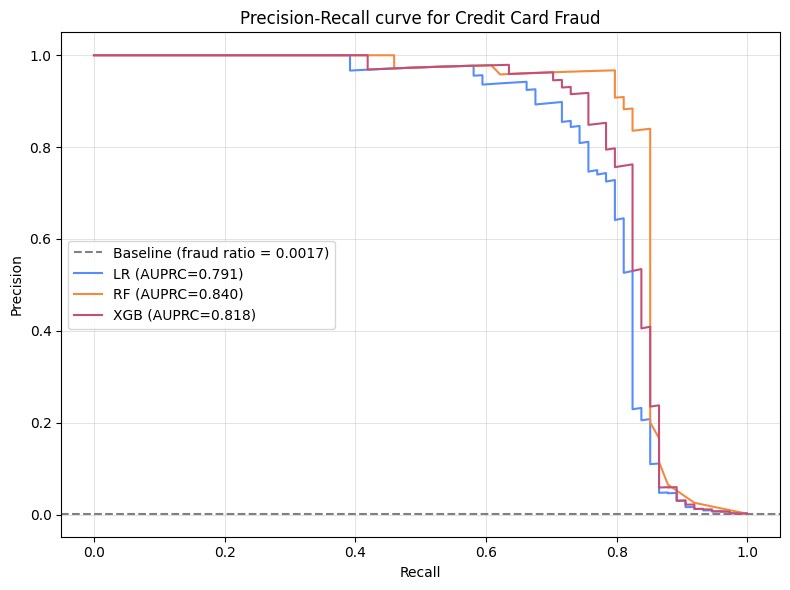

Processing IEEE-CIS...


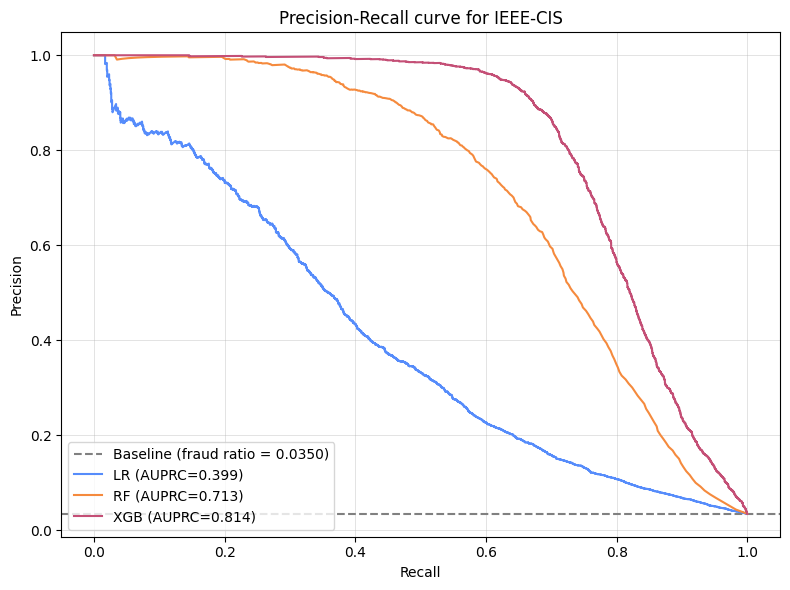

Processing PaySim...


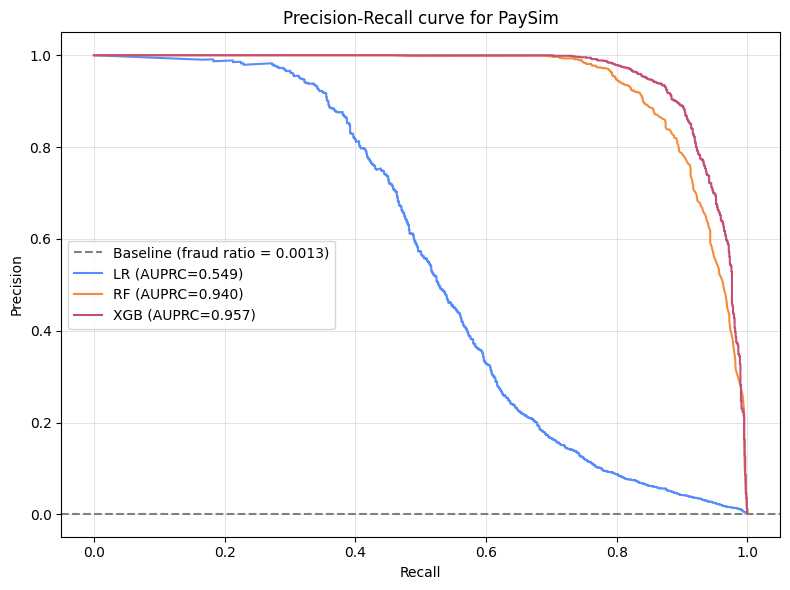

Processing AIZBank...


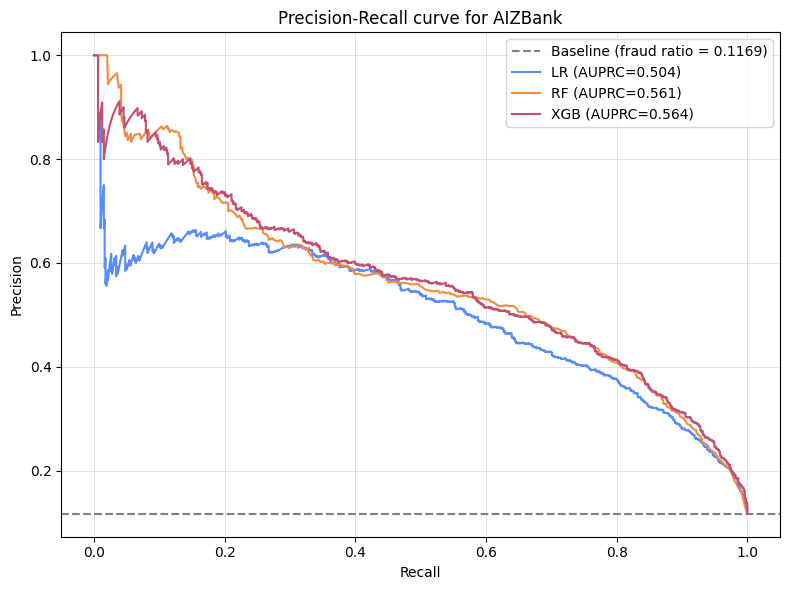

Processing Elliptic (Bitcoin)...


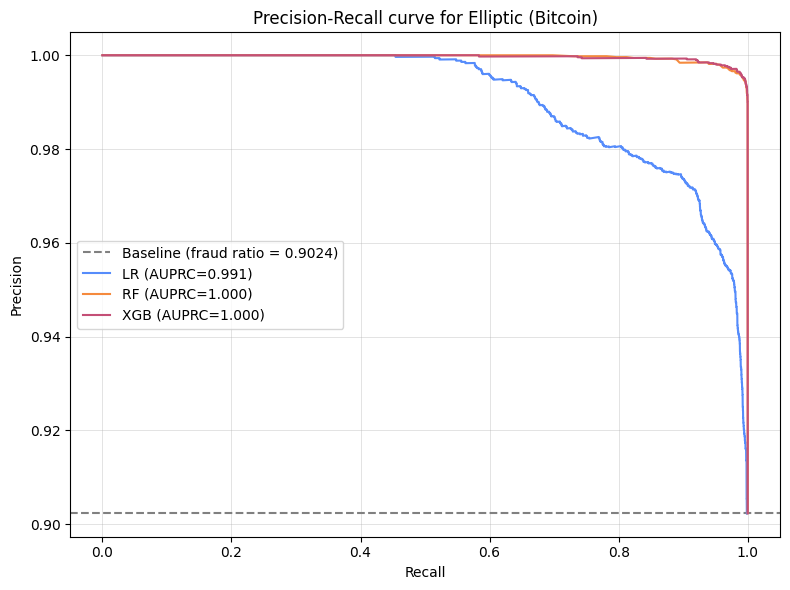

Processing Amazon Reviews...


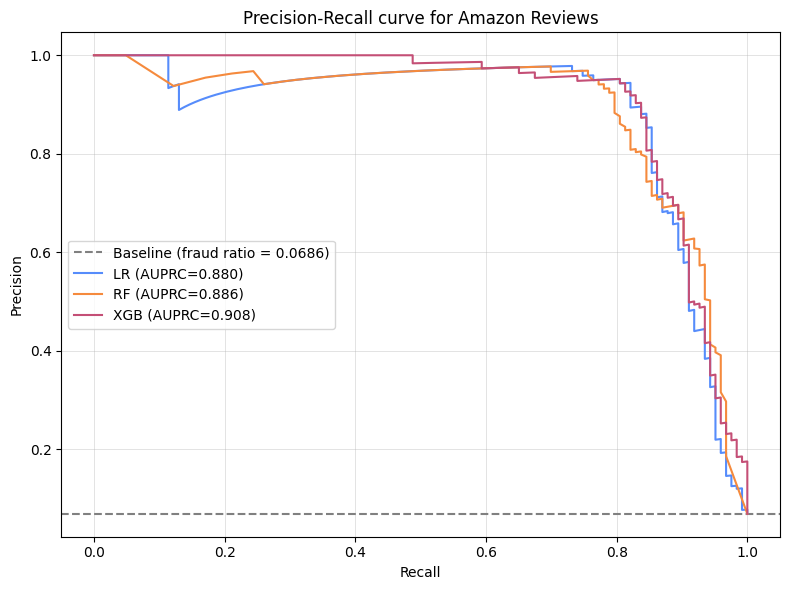

Processing Yelp Reviews...


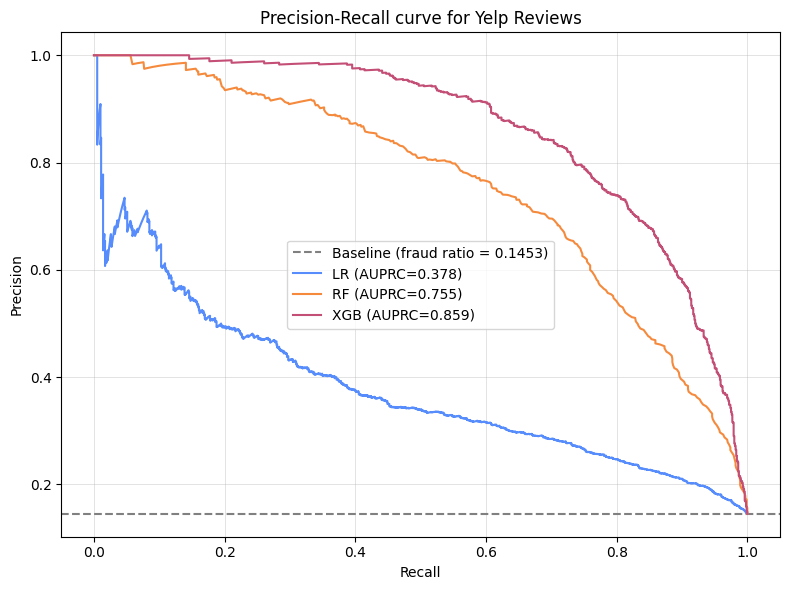

Processing Click Fraud...


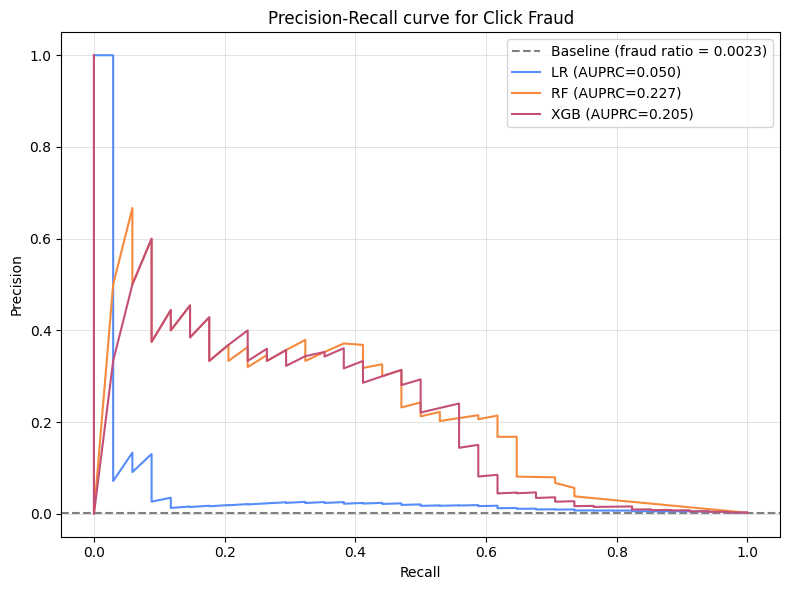

Processing Social Honeypot...


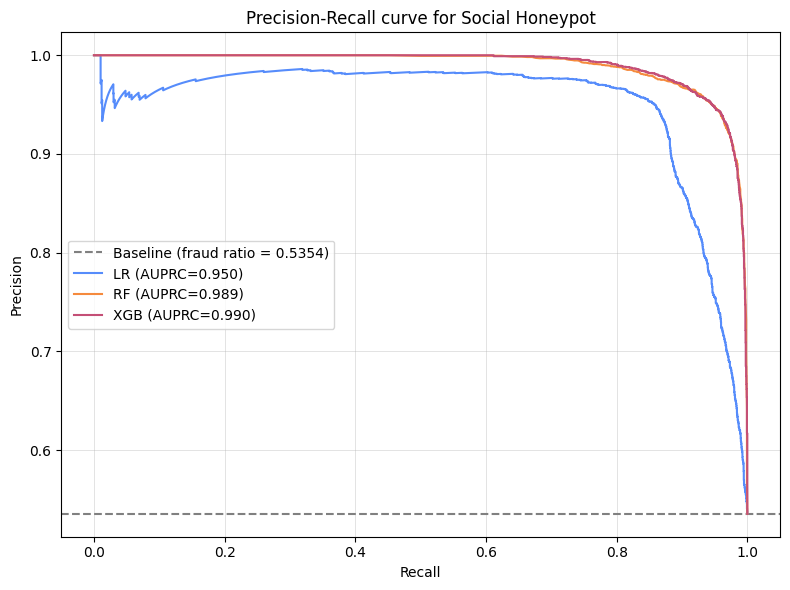

Processing Cresci-2017...


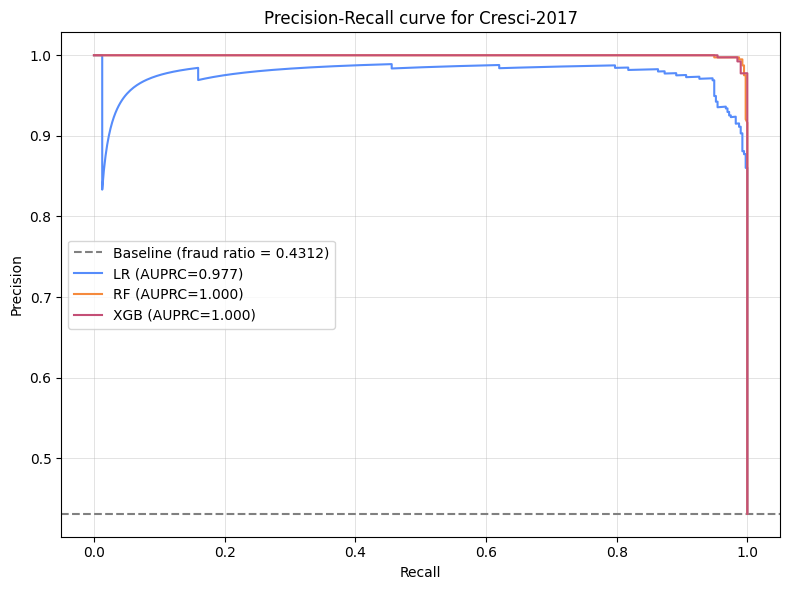

Processing Midterm-2018...


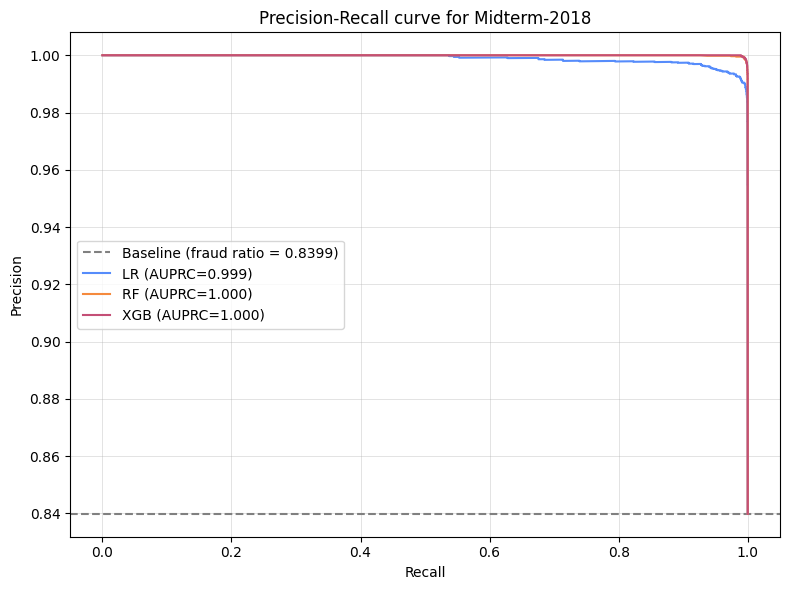

Processing MGTAB...


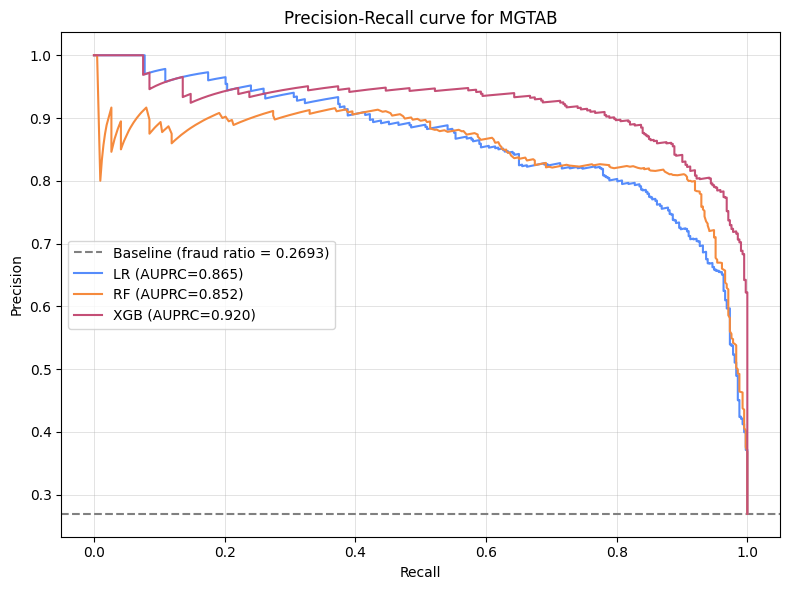

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
import os
import ast

# ------------------------------------------------------------
# Настройки
# ------------------------------------------------------------
DATA_ROOT = "final_data_encoded"
SEED = 42
TRAIN_SIZE = 0.7
VAL_SIZE = 0.15
TEST_SIZE = 0.15

dataset_order = [
    "Credit Card Fraud",
    "IEEE-CIS",
    "PaySim",
    "AIZBank",
    "Elliptic (Bitcoin)",
    "Amazon Reviews",
    "Yelp Reviews",
    "Click Fraud",
    "Social Honeypot",
    "Cresci-2017",
    "Midterm-2018",
    "MGTAB"
]

def load_encoded_dataset(name):
    X = np.load(os.path.join(DATA_ROOT, f"{name.replace(' ', '_')}_X.npy"))
    y = np.load(os.path.join(DATA_ROOT, f"{name.replace(' ', '_')}_y.npy"))
    return X, y

def split_stratified(X, y, train_ratio, val_ratio, test_ratio, random_state):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=val_ratio+test_ratio, stratify=y, random_state=random_state
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=test_ratio/(val_ratio+test_ratio),
        stratify=y_temp, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def load_best_params():
    lr_df = pd.read_csv("lr_results_encoded.csv")
    lr_params = {row['Dataset']: row.get('Best_C', 1.0) for _, row in lr_df.iterrows()}

    rf_df = pd.read_csv("rf_results_encoded.csv")
    rf_params = {}
    for _, row in rf_df.iterrows():
        ds = row['Dataset']
        max_depth = row.get('Best_max_depth', None)
        if pd.isna(max_depth) or max_depth == 'nan':
            max_depth = None
        else:
            max_depth = int(max_depth)
        min_samples_leaf = int(row.get('Best_min_samples_leaf', 1))
        max_features = row.get('Best_max_features', 'sqrt')
        if max_features == 'nan':
            max_features = None
        rf_params[ds] = {'max_depth': max_depth, 'min_samples_leaf': min_samples_leaf, 'max_features': max_features}

    xgb_df = pd.read_csv("xgb_results_encoded.csv")
    xgb_params = {}
    for _, row in xgb_df.iterrows():
        ds = row['Dataset']
        best_params_str = row['Best_params']
        best_params_str = best_params_str.replace("np.float64(", "").replace(")", "")
        best_params_str = best_params_str.replace("np.int64(", "").replace(")", "")
        best_params = ast.literal_eval(best_params_str)
        xgb_params[ds] = {
            'learning_rate': best_params.get('learning_rate', 0.1),
            'n_estimators': best_params.get('n_estimators', 100),
            'max_depth': best_params.get('max_depth', 3),
            'reg_lambda': best_params.get('reg_lambda', 1.0),
            'subsample': best_params.get('subsample', 1.0),
            'colsample_bytree': best_params.get('colsample_bytree', 1.0),
        }
    return lr_params, rf_params, xgb_params

lr_params, rf_params, xgb_params = load_best_params()

# ------------------------------------------------------------
# Построение PR-кривых
# ------------------------------------------------------------
for ds in dataset_order:
    print(f"Processing {ds}...")
    X, y = load_encoded_dataset(ds)
    X_train, X_val, X_test, y_train, y_val, y_test = split_stratified(
        X, y, TRAIN_SIZE, VAL_SIZE, TEST_SIZE, SEED
    )
    baseline = y_test.mean()
    plt.figure(figsize=(8,6))
    plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline (fraud ratio = {baseline:.4f})')

    # Logistic Regression
    if ds in lr_params:
        lr = LogisticRegression(C=lr_params[ds], class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=SEED)
        lr.fit(X_train, y_train)
        proba = lr.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, proba)
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f'LR (AUPRC={pr_auc:.3f})')

    # Random Forest
    if ds in rf_params:
        p = rf_params[ds]
        rf = RandomForestClassifier(n_estimators=500, class_weight='balanced_subsample', n_jobs=-1, random_state=SEED, **p)
        rf.fit(X_train, y_train)
        proba = rf.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, proba)
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f'RF (AUPRC={pr_auc:.3f})')

    # XGBoost
    if ds in xgb_params:
        p = xgb_params[ds]
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
        xgb_model = xgb.XGBClassifier(
            learning_rate=p['learning_rate'], n_estimators=p['n_estimators'], max_depth=p['max_depth'],
            reg_lambda=p['reg_lambda'], subsample=p['subsample'], colsample_bytree=p['colsample_bytree'],
            objective='binary:logistic', tree_method='hist', scale_pos_weight=scale_pos_weight,
            random_state=SEED, verbosity=0
        )
        xgb_model.fit(X_train, y_train)
        proba = xgb_model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, proba)
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f'XGB (AUPRC={pr_auc:.3f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall curve for {ds}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig(f"pr_curve_{ds.replace(' ', '_')}.png", dpi=150)
    plt.show()